# Dubai climate and reference evapotranspiration

**What this notebook answers:** how much water does a plant in Dubai lose to
the air each day, how confident can we be in that number, and what does the
soil actually do in response?

Everything downstream - how much to irrigate, when, and whether a machine
learning model helps - rests on this single quantity. If it is wrong, nothing
built on top of it can be right, so it is worth establishing carefully before
going further.

**The data.** Thirty years of daily observations for Dubai from NASA POWER,
1995 to 2024. NASA POWER combines satellite measurements of sunlight with a
global weather reanalysis. It is public, free, needs no account, and can be
re-downloaded by anyone who wants to check this work.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt

from irrigation.viz import apply_style, ACTUAL

apply_style()

from irrigation.data.nasa_power import load_metadata, load_records, load_weather
from irrigation.climate.et0_series import et0_for_day
from irrigation.climate.dubai import normals_day

records = load_records()
weather = load_weather()
metadata = load_metadata()

et0 = np.array([et0_for_day(day).et0_mm_day for day in weather])
# From the records, whose `date` is never None - `DailyWeather.date` is
# optional because a generated day has no calendar date. The two lists are
# built one-to-one from the same source, so the indices still line up.
years = np.array([record.date.year for record in records])
months = np.array([record.date.month for record in records])

cell = metadata["grid_cell_point"]
print(f"Days of record : {len(records):,}")
print(f"Period         : {records[0].date} to {records[-1].date}")
print(f"Location       : {cell['latitude']:.2f} N, {cell['longitude']:.2f} E")
print(f"Missing values : {30 * 365 + 8 - len(records)}")


Days of record : 10,958
Period         : 1995-01-01 to 2024-12-31
Location       : 25.25 N, 55.33 E
Missing values : 0


## The Dubai year

Reference evapotranspiration, written **ET0**, is the depth of water a
standard grass surface loses per day - to evaporation from the soil and
transpiration through the leaves combined. It is measured in millimetres per
day, which is convenient: 1 mm of ET0 is one litre of water lost per square
metre.

The chart below is the whole irrigation problem in one picture.


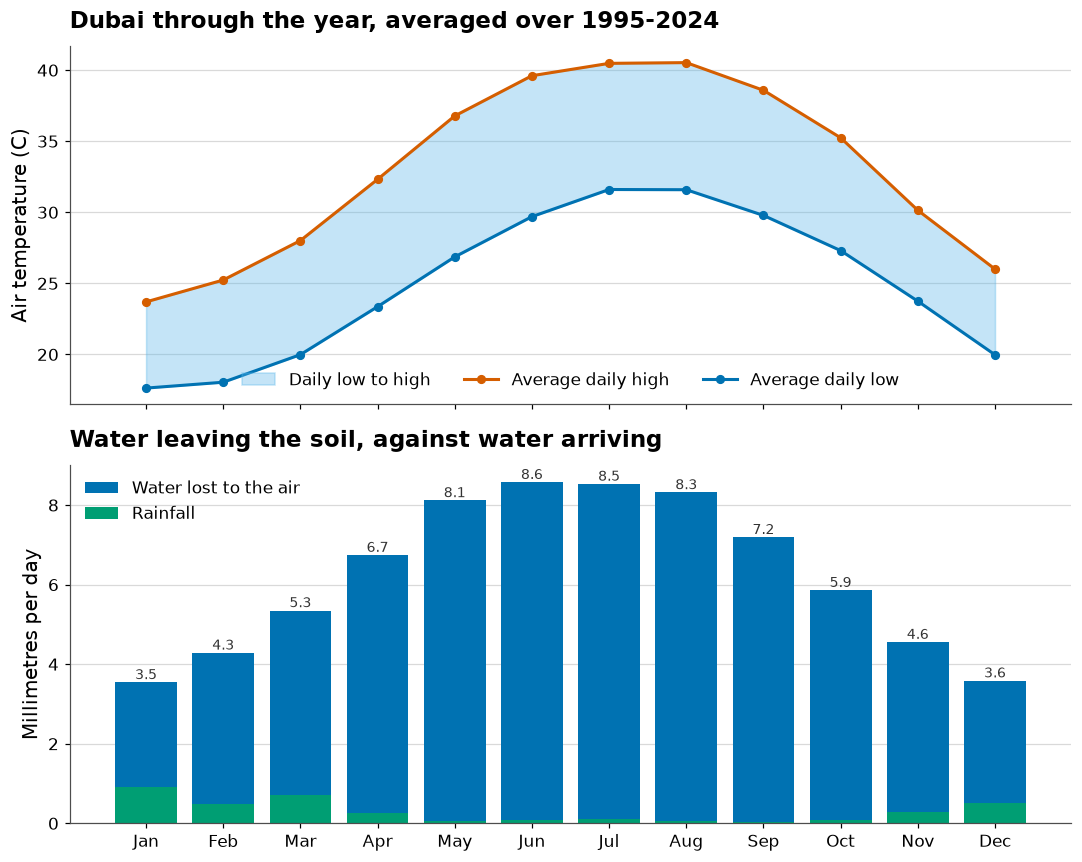

Average annual rainfall : 109 mm
Wettest month           : Jan, 0.90 mm/day on average
Peak water demand       : 8.6 mm/day
Ratio at the peak       : 117 to 1


In [2]:
monthly_et0 = np.array([et0[months == m].mean() for m in range(1, 13)])
monthly_tmax = np.array([r.tmax_c for r in records])
monthly_tmin = np.array([r.tmin_c for r in records])
record_months = np.array([r.date.month for r in records])

tmax_by_month = np.array([monthly_tmax[record_months == m].mean() for m in range(1, 13)])
tmin_by_month = np.array([monthly_tmin[record_months == m].mean() for m in range(1, 13)])
# Millimetres per DAY, matching the ET0 units they are plotted against.
# Monthly totals on the same axis would be about 30x taller and would suggest
# winter rainfall exceeds demand, which is the opposite of the truth.
rain_by_month = np.array([
    np.mean([r.rainfall_mm for r in records if r.date.month == m])
    for m in range(1, 13)
])
annual_rainfall = sum(r.rainfall_mm for r in records) / 30.0

labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
x = np.arange(12)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].fill_between(x, tmin_by_month, tmax_by_month, color="#56B4E9",
                     alpha=0.35, label="Daily low to high")
axes[0].plot(x, tmax_by_month, color="#D55E00", marker="o", label="Average daily high")
axes[0].plot(x, tmin_by_month, color="#0072B2", marker="o", label="Average daily low")
axes[0].set_ylabel("Air temperature (C)")
axes[0].set_title("Dubai through the year, averaged over 1995-2024")
# Lower centre: temperature peaks mid-year, so an upper legend sits on top of
# the very curves it labels.
axes[0].legend(loc="lower center", ncol=3)

bars = axes[1].bar(x, monthly_et0, color="#0072B2", label="Water lost to the air")
axes[1].bar(x, rain_by_month, color="#009E73", label="Rainfall")
axes[1].set_ylabel("Millimetres per day")
axes[1].set_xticks(x, labels)
axes[1].set_title("Water leaving the soil, against water arriving")
axes[1].legend(loc="upper left")

for index, value in enumerate(monthly_et0):
    axes[1].annotate(f"{float(value):.1f}", (index, value), ha="center",
                     va="bottom", fontsize=9, color="#333333")

plt.tight_layout()
plt.show()

print(f"Average annual rainfall : {annual_rainfall:.0f} mm")
print(f"Wettest month           : {labels[int(np.argmax(rain_by_month))]}, "
      f"{float(max(rain_by_month)):.2f} mm/day on average")
print(f"Peak water demand       : {float(max(monthly_et0)):.1f} mm/day")
print(f"Ratio at the peak       : {float(max(monthly_et0) / rain_by_month[int(np.argmax(monthly_et0))]):.0f} to 1")


**Read the lower panel first.** The blue bars are water leaving the soil; the
green bars are rain arriving. Both are in millimetres per day, so they are
directly comparable.

In July a square metre of grass loses about 8.5 litres a day and receives
about 0.1. Even January - the wettest month - averages under 1 mm/day of rain
against 3.5 mm/day of demand. Total annual rainfall is roughly 109 mm, against
annual demand above 2,200 mm.

There is no season in Dubai when rainfall meaningfully offsets demand. Every
drop a plant uses has to be applied deliberately, which is why getting the
amount right is worth effort.


## Is the number trustworthy?

The physics used here is the FAO-56 Penman-Monteith equation, the international
standard since 1998. The code implementing it is checked against the worked
examples published in FAO's own manual - but those examples are Bangkok,
Brussels and Lyon. None of them is a desert.

So the check that matters is a different one: build the same quantity **twice,
from unrelated sources**, and see whether the two agree.

- **Route one** starts from published monthly climate normals for Dubai - the
  kind of table in an almanac - and generates a smooth year from them.
- **Route two** starts from thirty years of NASA satellite and reanalysis data.

Nothing connects them. Neither was adjusted to match the other.


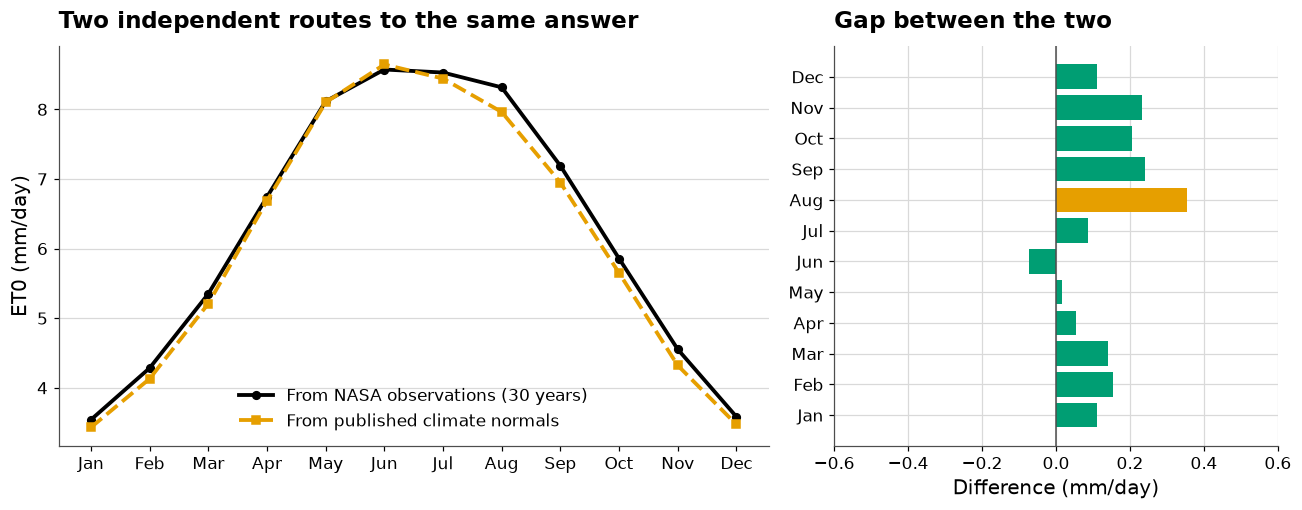

NASA observations, mean annual ET0 : 2,275 mm
Published normals, annual ET0      : 2,224 mm
Disagreement                       : 2.2%


In [3]:
synthetic_daily = np.array([et0_for_day(normals_day(d)).et0_mm_day for d in range(1, 366)])
synthetic_months = np.array([
    (np.datetime64("2001-01-01") + np.timedelta64(d - 1, "D")).astype("datetime64[M]").astype(int) % 12 + 1
    for d in range(1, 366)
])
synthetic_by_month = np.array([synthetic_daily[synthetic_months == m].mean() for m in range(1, 13)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8),
                         gridspec_kw={"width_ratios": [1.6, 1]})

axes[0].plot(x, monthly_et0, color=ACTUAL, marker="o", linewidth=2.5,
             label="From NASA observations (30 years)")
axes[0].plot(x, synthetic_by_month, color="#E69F00", marker="s", linestyle="--",
             linewidth=2.5, label="From published climate normals")
axes[0].set_xticks(x, labels)
axes[0].set_ylabel("ET0 (mm/day)")
axes[0].set_title("Two independent routes to the same answer")
# Lower centre: the curve peaks mid-year, so the usual upper-left position
# puts the legend text straight through the line it is labelling.
axes[0].legend(loc="lower center")

difference = monthly_et0 - synthetic_by_month
colours = ["#009E73" if abs(d) < 0.25 else "#E69F00" for d in difference]
axes[1].barh(x, difference, color=colours)
axes[1].axvline(0, color="#4D4D4D", linewidth=1)
axes[1].set_yticks(x, labels)
axes[1].set_xlabel("Difference (mm/day)")
axes[1].set_title("Gap between the two")
axes[1].set_xlim(-0.6, 0.6)
axes[1].grid(axis="x")

plt.tight_layout()
plt.show()

annual_real = np.array([et0[years == y].sum() for y in range(1995, 2025)])
print(f"NASA observations, mean annual ET0 : {float(annual_real.mean()):,.0f} mm")
print(f"Published normals, annual ET0      : {float(synthetic_daily.sum()):,.0f} mm")
print(f"Disagreement                       : "
      f"{float(abs(annual_real.mean() - synthetic_daily.sum()) / annual_real.mean() * 100):.1f}%")


**They agree to about 2%, and the largest monthly gap is under 0.4 mm/day.**

That is meaningful evidence. Two derivations sharing no inputs do not land on
the same seasonal curve by accident, so both are very likely right.

This check has caught a real error before. An earlier version of this project
fed wind speed into the equation at the height it is *reported* - 10 metres -
rather than the 2 metres the equation requires. Annual ET0 came out around
2,450 mm. The seasonal shape looked perfect, every chart looked reasonable,
and the error was roughly 9%. Only a magnitude comparison against independent
data exposed it.


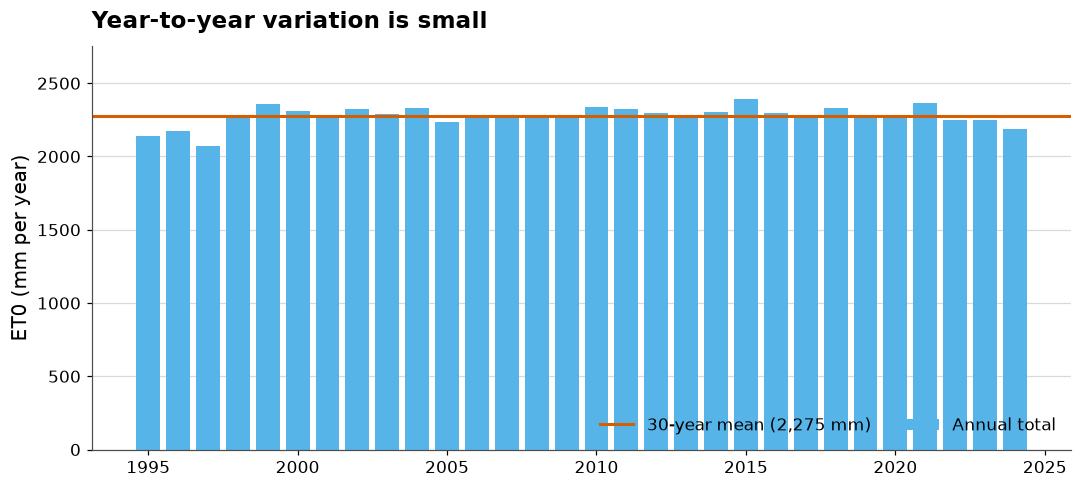

Range across 30 years : 2,071 to 2,392 mm
Standard deviation    : 65 mm (2.9% of the mean)


In [4]:
fig, ax = plt.subplots(figsize=(10, 4.6))

ax.bar(np.arange(1995, 2025), annual_real, color="#56B4E9", label="Annual total")
ax.axhline(annual_real.mean(), color="#D55E00", linewidth=2,
           label=f"30-year mean ({float(annual_real.mean()):,.0f} mm)")
ax.set_ylabel("ET0 (mm per year)")
ax.set_ylim(0, annual_real.max() * 1.15)
ax.set_title("Year-to-year variation is small")
ax.legend(loc="lower right", ncol=2)

plt.tight_layout()
plt.show()

print(f"Range across 30 years : {float(annual_real.min()):,.0f} to {float(annual_real.max()):,.0f} mm")
print(f"Standard deviation    : {float(annual_real.std()):,.0f} mm "
      f"({float(annual_real.std() / annual_real.mean() * 100):.1f}% of the mean)")


Annual demand varies by only about 3% from year to year. For a client this is
the good news buried in the data: **irrigation demand in Dubai is highly
predictable at the annual scale.** Budgeting water for next year is not the
hard problem. Deciding what to do *this Tuesday* is.


## What the soil does

NASA POWER also publishes modelled root-zone soil wetness for the same grid
cell - how full the soil is, on a scale from 0 (bone dry) to 1 (saturated).

An important caveat, stated plainly: **this grid cell is mostly bare desert,
not farmland.** It describes how untouched Dubai sand behaves, which is
genuinely useful - it is real, measured independently of anything in this
project - but it is not a picture of an irrigated field.


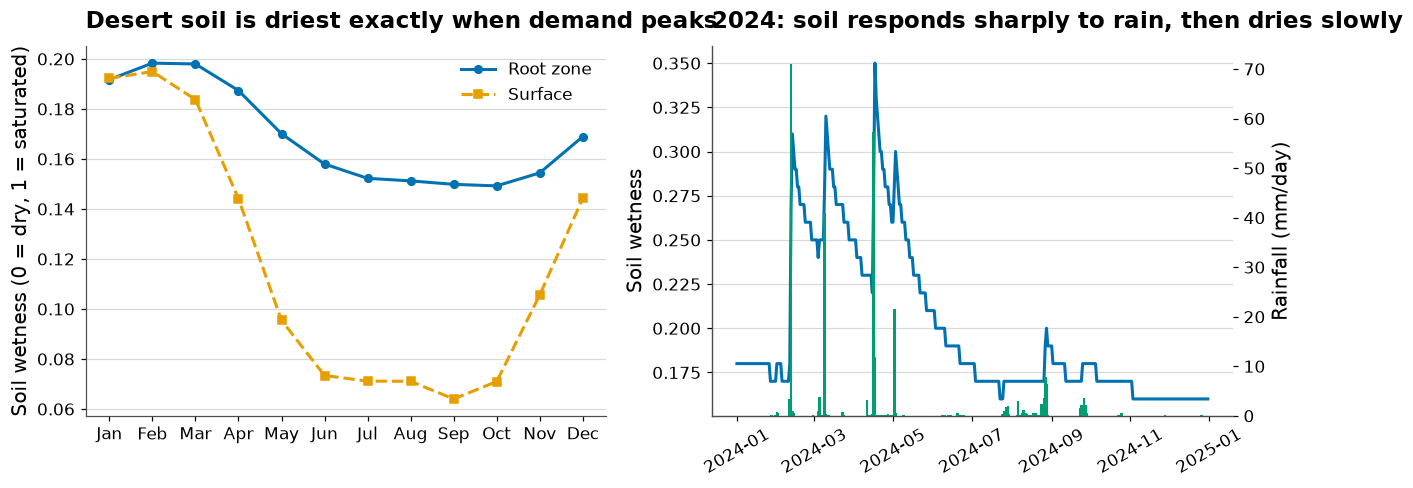

Root-zone wetness: 0.140 to 0.390, mean 0.169
Days with measurable rain: 714 out of 10,958 (6.5%)


In [5]:
wetness = np.array([r.wetness_root for r in records])
wetness_top = np.array([r.wetness_top for r in records])
rain = np.array([r.rainfall_mm for r in records])

wet_by_month = np.array([wetness[record_months == m].mean() for m in range(1, 13)])
top_by_month = np.array([wetness_top[record_months == m].mean() for m in range(1, 13)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

axes[0].plot(x, wet_by_month, color="#0072B2", marker="o", label="Root zone")
axes[0].plot(x, top_by_month, color="#E69F00", marker="s", linestyle="--", label="Surface")
axes[0].set_xticks(x, labels)
axes[0].set_ylabel("Soil wetness (0 = dry, 1 = saturated)")
axes[0].set_title("Desert soil is driest exactly when demand peaks")
axes[0].legend()

recent = [(r.date, r.wetness_root, r.rainfall_mm) for r in records if r.date.year == 2024]
dates = [d for d, _, _ in recent]
axes[1].plot(dates, [w for _, w, _ in recent], color="#0072B2", label="Root-zone wetness")
rain_axis = axes[1].twinx()
rain_axis.bar(dates, [p for _, _, p in recent], color="#009E73", width=2.0, label="Rainfall")
rain_axis.set_ylabel("Rainfall (mm/day)")
rain_axis.grid(False)
axes[1].set_ylabel("Soil wetness")
axes[1].set_title("2024: soil responds sharply to rain, then dries slowly")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print(f"Root-zone wetness: {float(wetness.min()):.3f} to {float(wetness.max()):.3f}, mean {float(wetness.mean()):.3f}")
print(f"Days with measurable rain: {int((rain > 0.5).sum())} out of {len(rain):,} "
      f"({float((rain > 0.5).mean() * 100):.1f}%)")


Two things stand out.

**The soil is at its driest in exactly the months demand is highest.** There is
no natural buffer to draw on in summer.

**Rain arrives as sharp spikes, then the soil dries slowly over weeks.** That
slow recession is the signal a model can learn, and it is what the next
notebook tries to predict.

---

## Summary

| Question                                | Answer                                                   |
|-----------------------------------------|----------------------------------------------------------|
| How much water does Dubai grass lose?   | About 2,275 mm/year; 8.5 mm/day in July                  |
| How reliable is that figure?            | Two independent derivations agree within 2%              |
| Does rain help?                         | Barely - 6.5% of days exceed 0.5 mm, 109 mm a year total |
| How much does demand vary year to year? | About 3%, so annual planning is easy                     |
| When is the soil driest?                | Summer - the same months demand peaks                    |

Next: [02 - Soil moisture sequence models](02_soil_moisture_sequence_models.ipynb)
